# squeeze_metrics — Pass-2b info / stats board

**Purpose:** lead-lag, markouts, incremental vs RV, ToD / stress regimes, use-map for GEX/VEX/squeeze.  
**Panel:** `panel_gex_options` **n=9**; spot_l2 **n=4** appendix; DDOI=**PROXY_trade_flow_DDOI**.  
**Artifacts:** `out/info_features/` · `out/feature_stats/` · `out/pass2/` · [`../APPLICATIONS.md`](../APPLICATIONS.md)  
**Gate:** **0 Promote** — Hold research tiles / monitors only. Never soft-Promote TOB-cross α.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "squeeze_metrics"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
ROOT = BOOK.parents[2]
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ROOT))
from _nb_common import (
    load_json, gex_day_table, safe_corr, partial_corr_vs_rv, lead_lag_day, SIGNAL_BOARD,
)
from certified_panel import load_certified, primary_days, spot_l2_days, gex_panel_days, DDOI_LABEL, GEX_PROXY_LABEL
from research.lib import squeeze  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("no figs dir", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

def print_board(rows=None):
    rows = rows or SIGNAL_BOARD
    print(f"{'id':34s} {'gate':6s} note")
    print("-" * 88)
    for i, g, n in rows:
        print(f"{i:34s} {g:6s} {n}")

CERT = load_certified()
PRIMARY = primary_days(CERT)
SPOT = spot_l2_days(CERT)
GEX_DAYS = gex_panel_days(CERT)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("panel_gex_options n=", len(GEX_DAYS), GEX_DAYS)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("DDOI label", DDOI_LABEL, "| GEX proxy", GEX_PROXY_LABEL)
print("trade_synth QUARANTINED — never primary; warehouse OI futures-only unused")


BOOK /home/dev/srv/ares-microstructure/research/books/squeeze_metrics
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
panel_gex_options n= 11 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-19', '2026-09-25', '2026-09-26', '2026-09-27', '2026-09-29', '2026-10-01']
spot_l2 subpanel n= 5 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-09-29', '2026-10-01']
DDOI label PROXY_trade_flow_DDOI | GEX proxy BS_GEX_trade_flow_DDOI
trade_synth QUARANTINED — never primary; warehouse OI futures-only unused


In [2]:

gex = load_json(OUT / "gex_implied_book" / "summary.json")
ddoi = load_json(OUT / "ddoi_positions" / "summary.json")
info_feat = load_json(OUT / "info_features" / "info_features.json")
feat_stats = load_json(OUT / "feature_stats" / "feature_stats.json")
cands = load_json(OUT / "info_features" / "candidates.json") or (info_feat or {}).get("candidates") or []
use_map = load_json(OUT / "info_features" / "use_map.json") or (info_feat or {}).get("use_map") or {}
panel = load_json(OUT / "gex_implied_book" / "panel_rows.json") or (gex or {}).get("rows") or []
tbl = gex_day_table(panel, CERT)
ok = tbl[tbl["ok"] == True].copy() if len(tbl) else tbl
print("n_ok", len(ok), "days", list(ok["day"]) if len(ok) else [])
print("info ok", bool(info_feat), "feature_stats ok", bool(feat_stats))
if info_feat:
    incr = info_feat.get("incremental") or {}
    print("promote_count", info_feat.get("promote_count"))
    print("partial(range,GEX|RV)", (incr.get("partial_range_gex_ctrl_rv") or {}).get("partial_r"))
    print("ΔR² GEX|RV", incr.get("delta_r2_gex_after_rv"),
          "VEX|RV+GEX", incr.get("delta_r2_vex_after_rv_gex"),
          "squeeze|GEX", incr.get("delta_r2_squeeze_after_gex"))
    print("day_feature PC1", (info_feat.get("day_feature_pca") or {}).get("pc1_explained"))
    print("scarce", (info_feat.get("regimes") or {}).get("scarce"))
else:
    print("info_features missing — run scripts/exp_info_features.py")
# persist light stats artifact (notebook-local mirror)
stats = {
    "n_ok": int(len(ok)),
    "days": list(ok["day"]) if len(ok) else [],
    "corr": {
        "gex_hl_rv": safe_corr(ok["gex"], ok["hl_rv"]) if len(ok) else None,
        "gex_hl_range": safe_corr(ok["gex"], ok["hl_range"]) if len(ok) else None,
        "vex_hl_rv": safe_corr(ok["vex"], ok["hl_rv"]) if len(ok) else None,
        "vex_hl_range": safe_corr(ok["vex"], ok["hl_range"]) if len(ok) else None,
        "gexplus_hl_range": safe_corr(ok["gex_plus"], ok["hl_range"]) if len(ok) else None,
        "gex_vex": safe_corr(ok["gex"], ok["vex"]) if len(ok) else None,
    },
    "partial_vs_rv": {
        "gexplus_range_given_rv": partial_corr_vs_rv(ok["gex_plus"], ok["hl_range"], ok["hl_rv"]) if len(ok) else None,
        "gex_range_given_rv": partial_corr_vs_rv(ok["gex"], ok["hl_range"], ok["hl_rv"]) if len(ok) else None,
    },
    "lead_lag_gex_rv": lead_lag_day(ok["gex"].to_numpy(), ok["hl_rv"].to_numpy()) if len(ok) >= 3 else {},
    "lead_lag_gex_range": lead_lag_day(ok["gex"].to_numpy(), ok["hl_range"].to_numpy()) if len(ok) >= 3 else {},
    "pass2b_incremental": (info_feat or {}).get("incremental"),
    "use_map": use_map,
    "ddoi_label": DDOI_LABEL,
    "promote": False,
    "decision_ceiling": "Hold",
}
stats_dir = OUT / "info_stats"
stats_dir.mkdir(parents=True, exist_ok=True)
(stats_dir / "info_stats.json").write_text(json.dumps(stats, indent=2, default=str))
print("wrote", stats_dir / "info_stats.json")


n_ok 9 days ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
info ok True feature_stats ok True
promote_count 0
partial(range,GEX|RV) -0.004827950073050882
ΔR² GEX|RV 1.0842724927684344e-05 VEX|RV+GEX 0.0005318213393881166 squeeze|GEX 0.0004378260233522946
day_feature PC1 0.6570001659012159
scarce ['2026-09-18', '2026-09-25', '2026-09-26', '2026-10-01']
wrote /home/dev/srv/ares-microstructure/research/books/squeeze_metrics/out/info_stats/info_stats.json


## Pass-2b figs (info + feature_stats)


**fig_incremental.png** — `out/info_features/figs/fig_incremental.png`

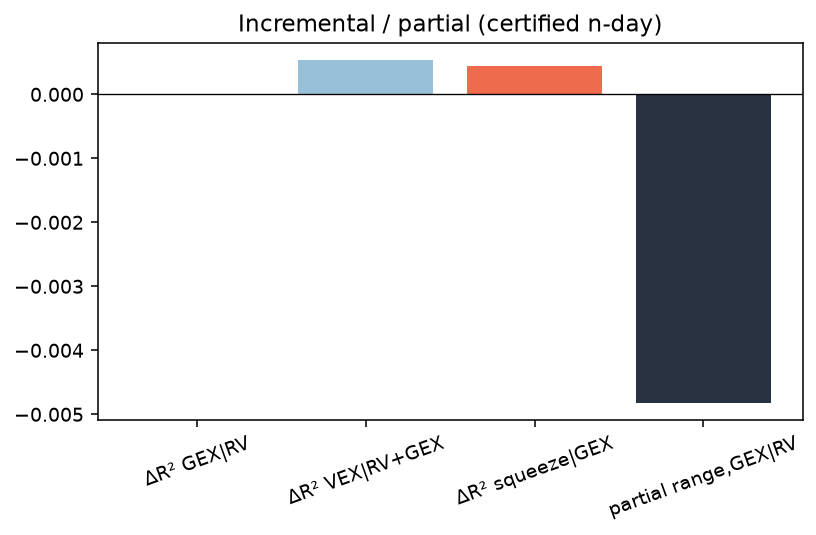

**fig_leadlag_day.png** — `out/info_features/figs/fig_leadlag_day.png`

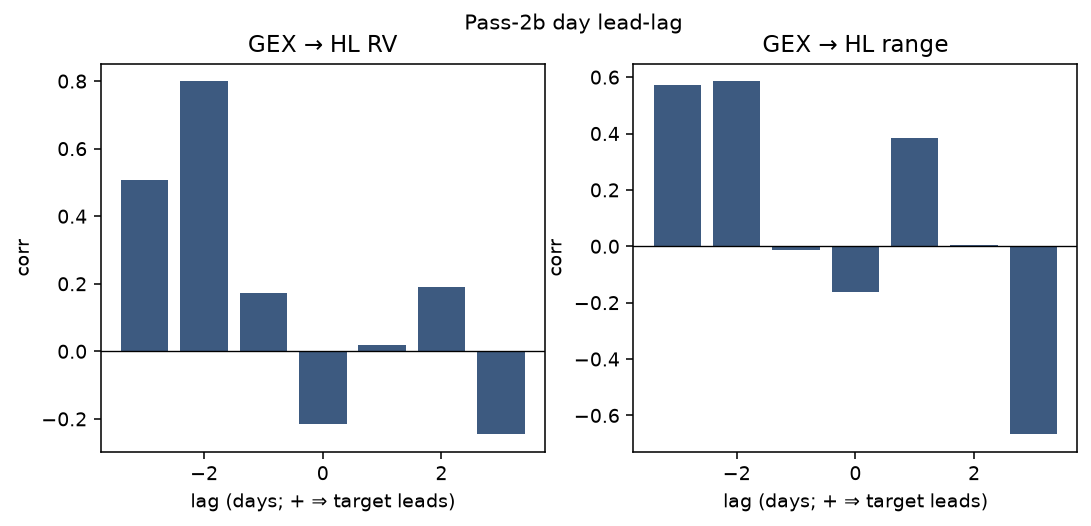

**fig_markout_regimes.png** — `out/info_features/figs/fig_markout_regimes.png`

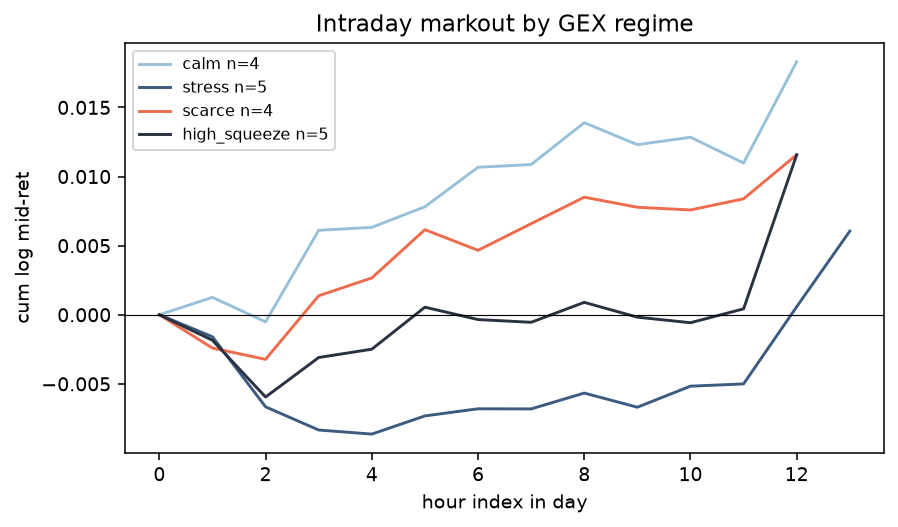

**fig_stress_calm_rv.png** — `out/info_features/figs/fig_stress_calm_rv.png`

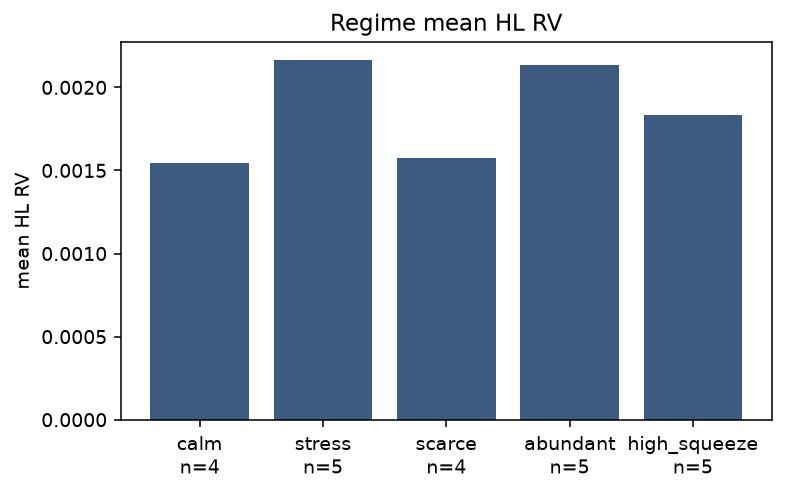

**fig_tod_rv.png** — `out/info_features/figs/fig_tod_rv.png`

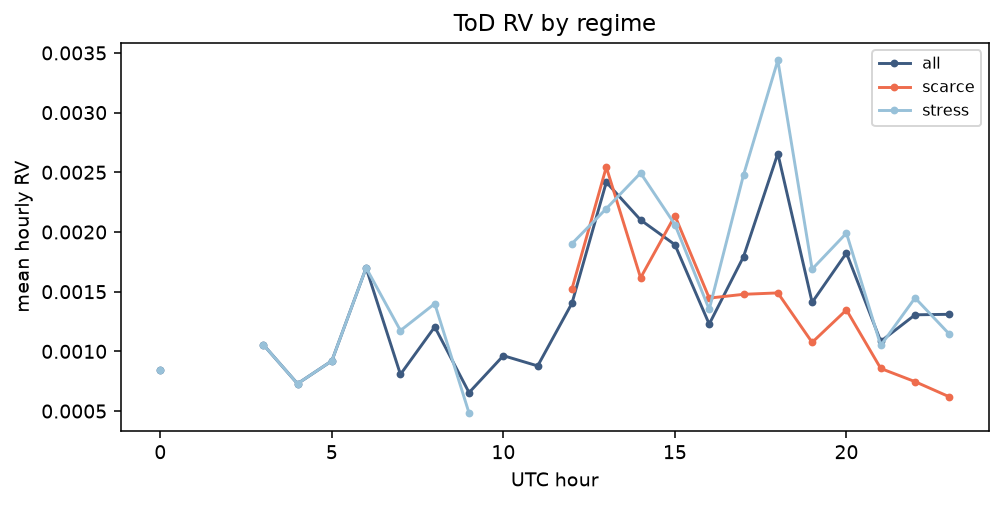

**fig_use_map.png** — `out/info_features/figs/fig_use_map.png`

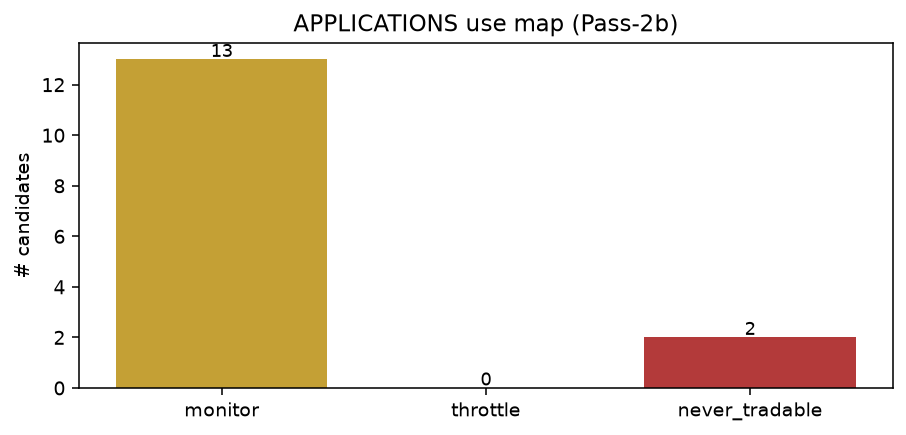

**fig_dep_ci.png** — `out/feature_stats/figs/fig_dep_ci.png`

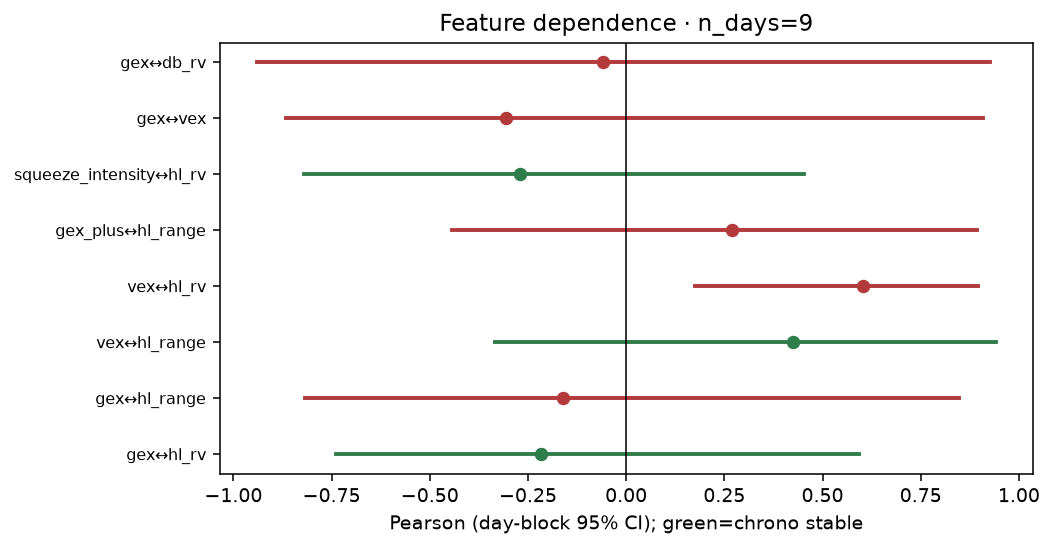

**fig_tod.png** — `out/feature_stats/figs/fig_tod.png`

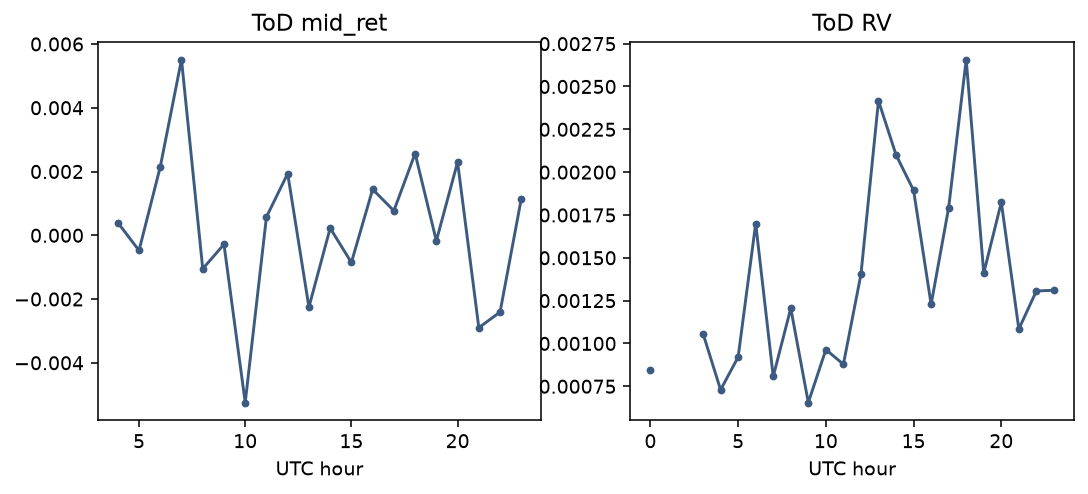

**fig_uni_moments.png** — `out/feature_stats/figs/fig_uni_moments.png`

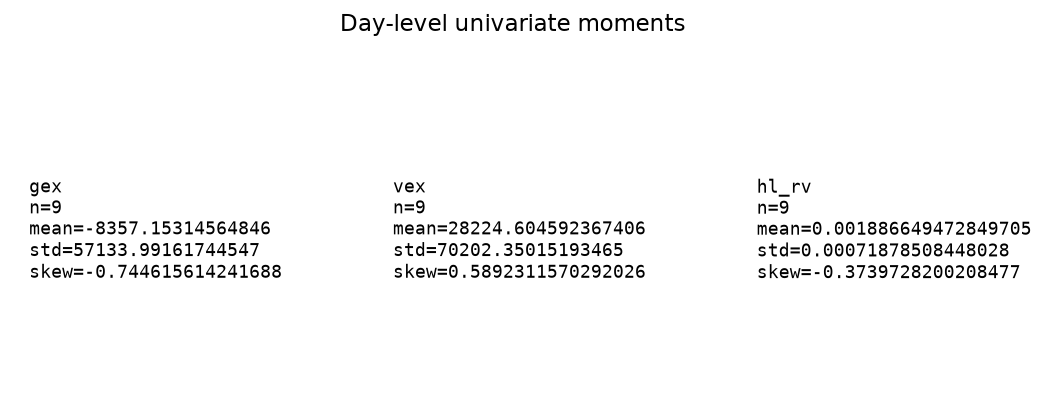

**fig_chrono_split.png** — `out/pass2/figs/fig_chrono_split.png`

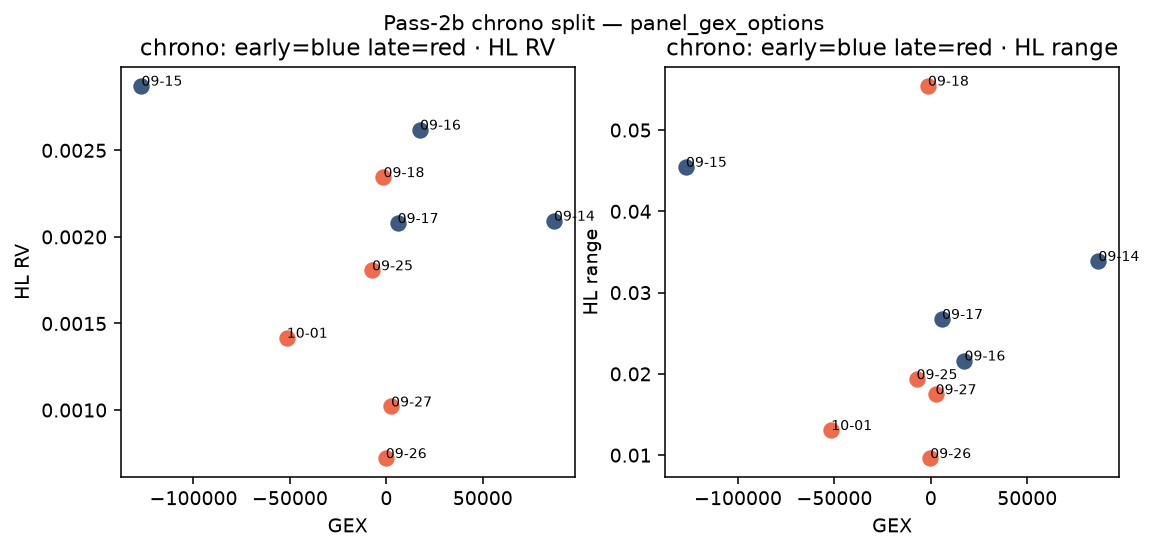

**fig_dayblock_ci.png** — `out/pass2/figs/fig_dayblock_ci.png`

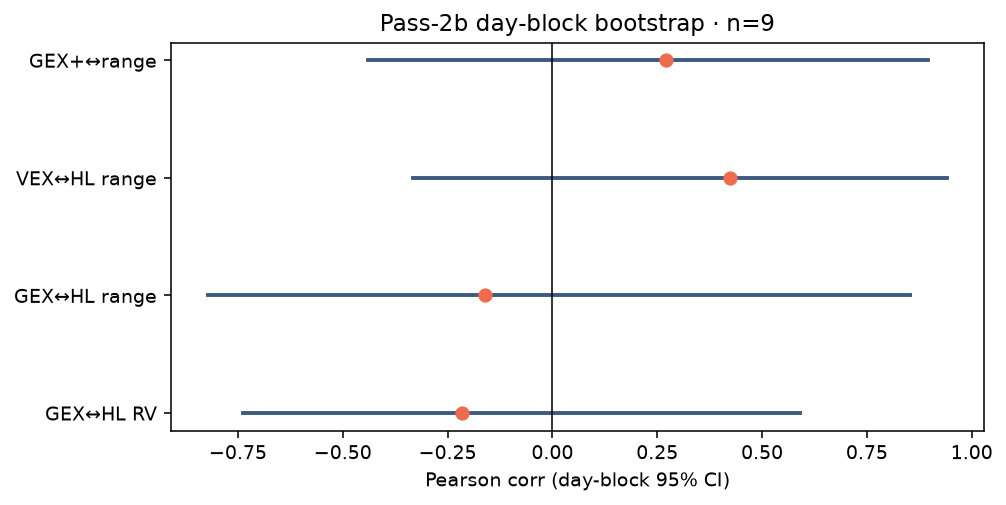

**fig_loo_corr.png** — `out/pass2/figs/fig_loo_corr.png`

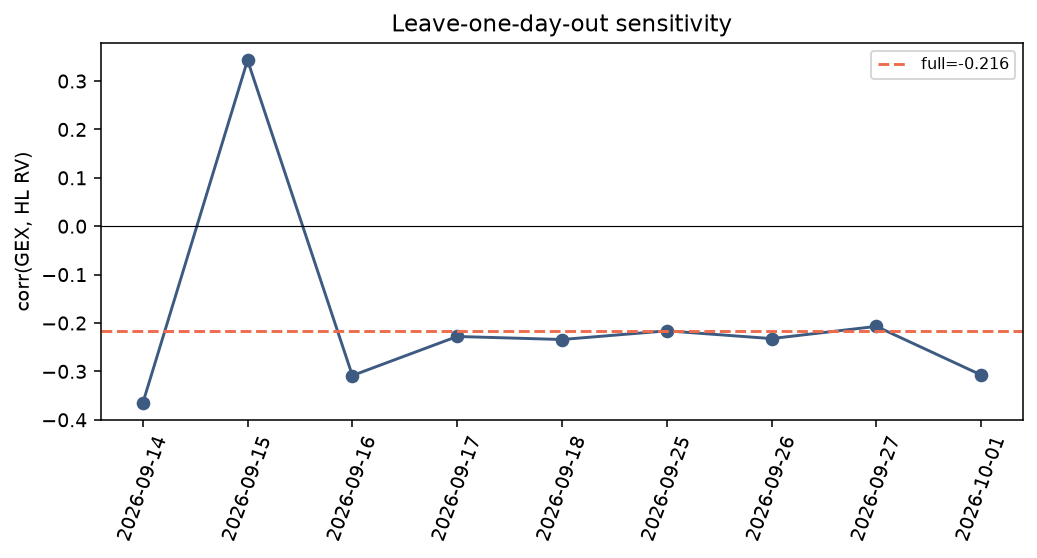

**fig_venue_drop.png** — `out/pass2/figs/fig_venue_drop.png`

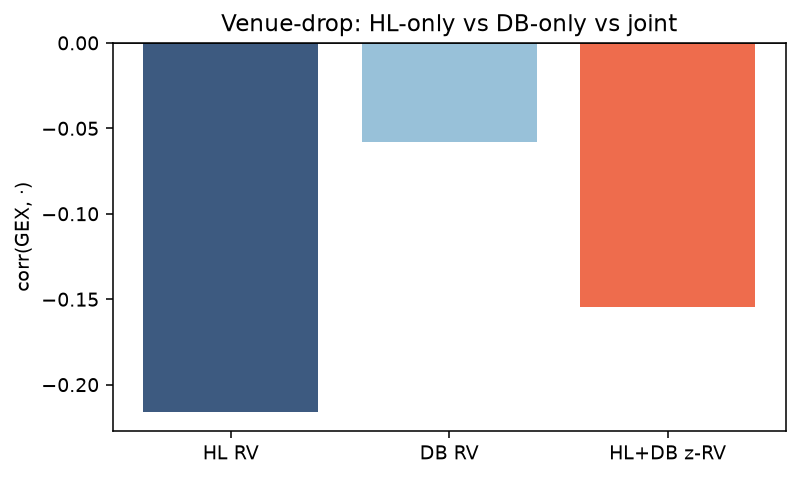

In [3]:

show_pngs(OUT / "info_features" / "figs")
show_pngs(OUT / "feature_stats" / "figs")
show_pngs(OUT / "pass2" / "figs")


## Correlation matrix (day panel)


,gex,vex,gex_plus,squeeze_intensity,hl_rv,hl_range,opt_trade_n
gex,1.000,-0.305,0.471,-0.411,-0.216,-0.161,-0.420
vex,-0.305,1.000,0.696,-0.489,0.603,0.424,0.744
gex_plus,0.471,0.696,1.000,-0.763,0.395,0.271,0.373
squeeze_intensity,-0.411,-0.489,-0.763,1.000,-0.270,0.047,-0.107
hl_rv,-0.216,0.603,0.395,-0.270,1.000,0.731,0.838
hl_range,-0.161,0.424,0.271,0.047,0.731,1.000,0.778
opt_trade_n,-0.420,0.744,0.373,-0.107,0.838,0.778,1.000


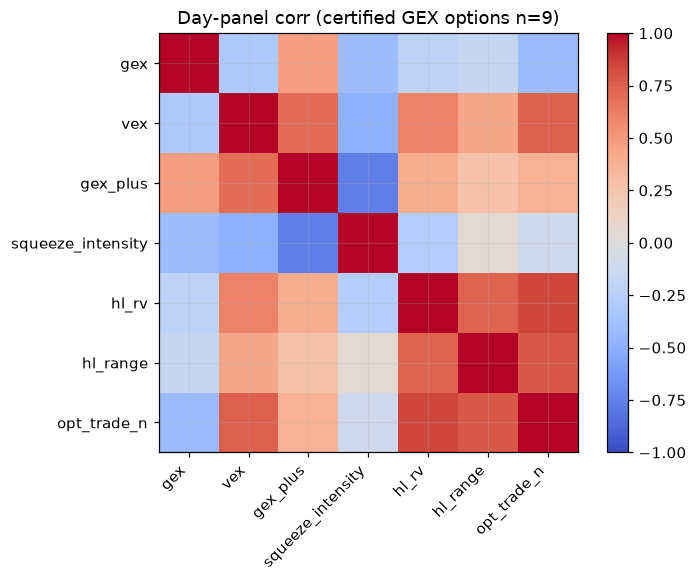

In [4]:

cols = ["gex","vex","gex_plus","squeeze_intensity","hl_rv","hl_range","opt_trade_n"]
if len(ok):
    c = ok[cols].astype(float).corr()
    display(c.round(3))
    fig, ax = plt.subplots(figsize=(6.8, 5.4))
    im = ax.imshow(c.values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha="right")
    ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
    ax.set_title("Day-panel corr (certified GEX options n=9)")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()
else:
    print("no ok days — run Pass-1 panels first")


## Lead-lag + incremental (Pass-2b)


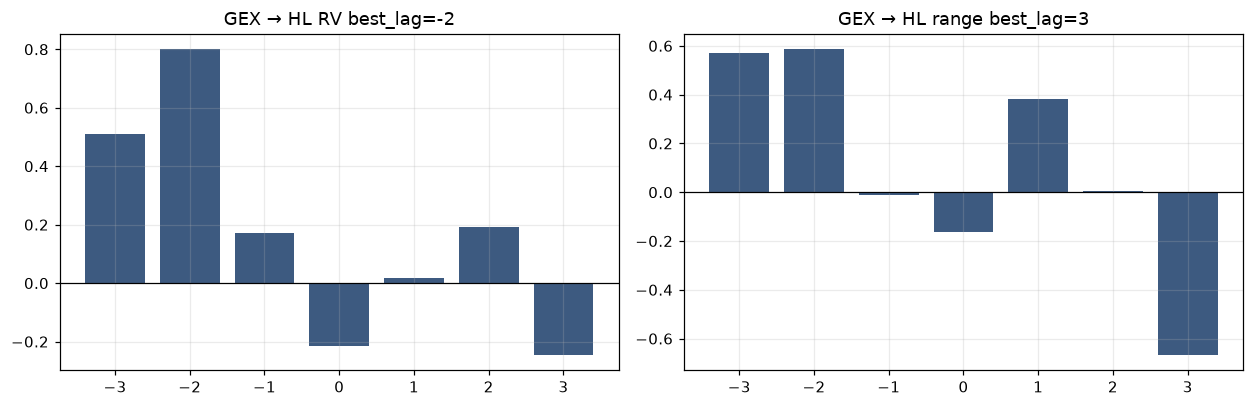

ΔR² GEX after RV 1.0842724927684344e-05
ΔR² VEX after RV+GEX 0.0005318213393881166
ΔR² squeeze after GEX 0.0004378260233522946
partial(range,GEX|RV) -0.004827950073050882
Note: descriptive only — not tradable IRF α


In [5]:

ll = (info_feat or {}).get("lead_lag") or {}
incr = (info_feat or {}).get("incremental") or {}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
for ax, key, title in (
    (axes[0], "gex->hl_rv", "GEX → HL RV"),
    (axes[1], "gex->hl_range", "GEX → HL range"),
):
    rec = ll.get(key) or {}
    lags, corrs = rec.get("lags") or [], rec.get("corr") or []
    if lags:
        ax.bar(lags, [c if c is not None else np.nan for c in corrs], color="#3d5a80")
        ax.axhline(0, color="k", lw=0.8)
        ax.set_title(f"{title} best_lag={rec.get('best_lag')}")
    else:
        ax.text(0.5, 0.5, "missing", ha="center", transform=ax.transAxes)
plt.tight_layout(); plt.show()
print("ΔR² GEX after RV", incr.get("delta_r2_gex_after_rv"))
print("ΔR² VEX after RV+GEX", incr.get("delta_r2_vex_after_rv_gex"))
print("ΔR² squeeze after GEX", incr.get("delta_r2_squeeze_after_gex"))
print("partial(range,GEX|RV)", (incr.get("partial_range_gex_ctrl_rv") or {}).get("partial_r"))
print("Note: descriptive only — not tradable IRF α")


## Stress / calm + use map


In [6]:

stress = (info_feat or {}).get("stress_calm") or {}
for k, rec in stress.items():
    if isinstance(rec, dict):
        print(k, "n", rec.get("n"), "mean_HL_RV", rec.get("mean_hl_rv"),
              "corr_gex_rv", (rec.get("corr_gex_hl_rv") or {}).get("pearson"))
print("use_map", json.dumps(use_map, indent=2))
if isinstance(cands, list) and cands:
    cdf = pd.DataFrame(cands)
    display(cdf[["id","decision","wire_as","use"]] if set(cdf.columns)>= {"id","decision","wire_as","use"} else cdf)


stress n 5 mean_HL_RV 0.0021622770976455264 corr_gex_rv -0.2504886846975378
calm n 4 mean_HL_RV 0.0015421149418549285 corr_gex_rv 0.11747266091002835
scarce n 4 mean_HL_RV 0.0015731349528480603 corr_gex_rv 0.1077359757381518
abundant n 5 mean_HL_RV 0.002137461088851021 corr_gex_rv -0.4170636210980757
high_squeeze n 5 mean_HL_RV 0.0018331938114776764 corr_gex_rv -0.615450023538491
use_map {
  "monitor": [
    "risk.gex_exposure",
    "risk.vex_exposure",
    "risk.squeeze_intensity",
    "liq.implied_book_scarcity",
    "info.gex_range_incremental",
    "info.squeeze_after_gex",
    "info.vex_incremental",
    "info.gex_leadlag_map",
    "info.gex_markout_regimes",
    "info.tod_factor_structure",
    "info.stress_vs_calm",
    "info.object_use_map",
    "info.kraken_spot_vs_2venue"
  ],
  "throttle": [],
  "never_tradable": [
    "alpha.tob_cross_arb",
    "data.trade_synth"
  ],
  "note": "Pass-2b: all Hold objects are monitors; Kill = never-tradable; no Promote wire"
}


,id,decision,wire_as,use
0,risk.gex_exposure,Hold,monitor,risk monitor strip — never sized α
1,risk.vex_exposure,Hold,monitor,risk / IV-join monitor
2,risk.squeeze_intensity,Hold,monitor,squeeze / scarcity strip
3,liq.implied_book_scarcity,Hold,monitor,liquidity friction context
4,info.gex_range_incremental,Hold,monitor,research tile — vol-overlap check
5,info.squeeze_after_gex,Hold,monitor,research — incremental squeeze
6,info.vex_incremental,Hold,monitor,research — VEX beyond GEX/RV
7,info.gex_leadlag_map,Hold,monitor,research tile / risk context — not IRF α
8,info.gex_markout_regimes,Hold,monitor,research / risk context
9,info.tod_factor_structure,Hold,monitor,commonality / regime strip


## DDOI coverage join


In [7]:

ddoi_rows = (ddoi or {}).get("rows") or []
ddf = pd.DataFrame(ddoi_rows)
if len(ddf) and len(ok):
    m = ok.merge(ddf[["day","n_trades","ddoi_abs_sum","ddoi_n_nonzero"]], on="day", how="left")
    display(m[["day","gex","hl_range","n_trades","ddoi_abs_sum","ddoi_mode","kraken"]].round(4))
    print("corr(|DDOI|, |GEX|)", safe_corr(m["ddoi_abs_sum"].abs(), m["gex"].abs()))
else:
    print("ddoi summary missing — run exp_ddoi_panel.py")


,day,gex,hl_range,n_trades,ddoi_abs_sum,ddoi_mode,kraken
0,2026-09-14,86891.2836,0.0339,2411,55861.0,PROXY_trade_flow_DDOI,absent_2venue
1,2026-09-15,-126980.8612,0.0455,4810,71805.0,PROXY_trade_flow_DDOI,absent_2venue
2,2026-09-16,17436.9415,0.0216,1504,19524.0,PROXY_trade_flow_DDOI,absent_2venue
3,2026-09-17,5832.2306,0.0268,1657,45144.0,PROXY_trade_flow_DDOI,absent_2venue
4,2026-09-18,-1491.2236,0.0555,2283,42133.0,PROXY_trade_flow_DDOI,absent_2venue
5,2026-09-25,-7410.1917,0.0193,1764,23412.0,PROXY_trade_flow_DDOI,spot_l2
6,2026-09-26,-308.6851,0.0096,215,2169.0,PROXY_trade_flow_DDOI,spot_l2
7,2026-09-27,2462.3547,0.0175,207,3423.0,PROXY_trade_flow_DDOI,spot_l2
8,2026-10-01,-51646.2271,0.0131,440,10140.0,PROXY_trade_flow_DDOI,spot_l2


corr(|DDOI|, |GEX|) 0.6919306511225038


## Signal board (info.*)


In [8]:

print_board([r for r in SIGNAL_BOARD if r[0].startswith("info.") or r[0] in (
    "risk.gex_exposure","risk.squeeze_falsifier_board","liq.gex_rv_link","alpha.tob_cross_arb","data.trade_synth"
)])
print("\\nArtifact written:", OUT / "info_stats" / "info_stats.json")
print("0 Promote · Hold tiles only · Kill TOB-cross α / trade_synth")


id                                 gate   note
----------------------------------------------------------------------------------------
risk.gex_exposure                  Hold   Σ PROXY_trade_flow_DDOI · BS-γ · panel_gex_options n=9 — monitor≠α
liq.gex_rv_link                    Hold   corr(GEX, HL RV)≈−0.22; day-block CI crosses 0 — research tile
risk.squeeze_falsifier_board       Hold   Pass-2b chrono / day-block / placebo / venue-drop / LOO — 0 Promote
info.gex_range_incremental         Hold   partial(range,GEX|RV)≈0 · ΔR²≈0 — vol-overlap honesty tile
info.squeeze_after_gex             Hold   ΔR²(squeeze|GEX) on range ~0 — research
info.vex_incremental               Hold   ΔR²(VEX|RV+GEX)~0 — research
info.gex_leadlag_map               Hold   Day lead-lag GEX→RV/range/mid_ret — descriptive not IRF α
info.gex_markout_regimes           Hold   Intraday cum mid-ret markouts by scarce/stress/calm — research
info.tod_factor_structure          Hold   ToD RV / mid_ret by regime + day-featur